<a href="https://colab.research.google.com/github/sathu0622/DL_Assigment/blob/feature%2Frajendram/CNN%20%2B%20Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**
This section focuses on building a Convolutional Neural Network (CNN) model enhanced with **data augmentation** techniques to improve generalization and reduce overfitting. The Fashion MNIST dataset is used again, which contains grayscale images of clothing items from ten categories.  
By applying transformations such as rotations, zooming, and shifting, the model is exposed to a wider variety of training examples without collecting new data. This helps the network learn more robust visual features.


# **Import Required Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# **Load and Preprocess the Dataset**

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Applying Data Augmentation**

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(x_train)

# **Building the CNN Model**

In [ ]:
model4 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Compiling the Model**

In [ ]:
model4.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# **Training the Model**

In [ ]:
history4 = model4.fit(datagen.flow(x_train, y_train, batch_size=64),
                      epochs=15,
                      validation_data=(x_test, y_test))

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 71ms/step - accuracy: 0.5869 - loss: 1.1165 - val_accuracy: 0.7791 - val_loss: 0.5516
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step - accuracy: 0.7498 - loss: 0.6599 - val_accuracy: 0.8164 - val_loss: 0.4792
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.7733 - loss: 0.5914 - val_accuracy: 0.8380 - val_loss: 0.4373
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.7969 - loss: 0.5457 - val_accuracy: 0.8519 - val_loss: 0.4066
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.8078 - loss: 0.5176 - val_accuracy: 0.8471 - val_loss: 0.4131
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - accuracy: 0.8186 - loss: 0.4918 - val_accuracy: 0.8713 - val_loss: 0.3520
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 72ms/step - accuracy: 0.8295 - loss: 0.4603 - val_accuracy: 0.8724 - val_loss: 0.3511
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.8327 - loss: 0.4512 - val_accurac

#**Evaluating the Model**

In [ ]:
test_loss, test_acc = model4.evaluate(x_test, y_test)
print(f"\nFinal Test Accuracy (CNN + Augmentation): {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8780 - loss: 0.3440

Final Test Accuracy (CNN + Augmentation): 0.8794


# **Visualizing Training Progress**

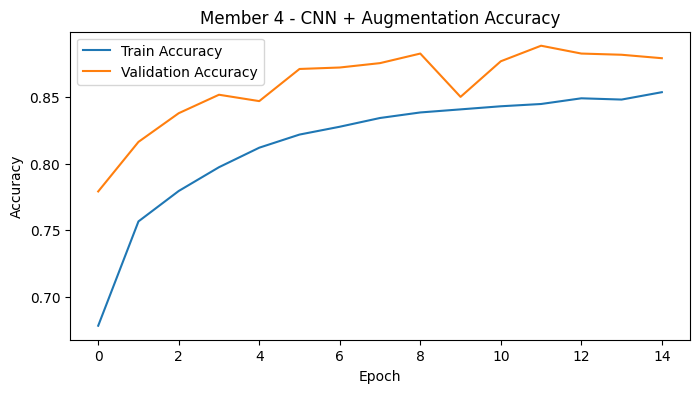

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history4.history['accuracy'], label='Train Accuracy')
plt.plot(history4.history['val_accuracy'], label='Validation Accuracy')
plt.title("Member 4 - CNN + Augmentation Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# **Custom Prediction**


📂 Upload a custom image (JPG/PNG of clothing item)...


Saving 788287593a4b07d40970f909b6006088.jpg_720x720q80.jpg to 788287593a4b07d40970f909b6006088.jpg_720x720q80.jpg


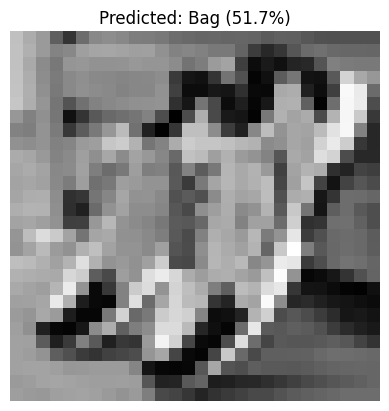

🧥 Predicted Class: Bag (51.69% confidence)


In [ ]:
# ===== CUSTOM PREDICTION (CNN + Data Augmentation) =====
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("\n📂 Upload a custom image (JPG/PNG of clothing item)...")
uploaded = files.upload()

for fname in uploaded.keys():
    path = fname

    # Load and preprocess image
    img = Image.open(path).convert("L")  # Convert to grayscale
    img = img.resize((28, 28))           # Resize to 28x28 (model input size)

    # Normalize and reshape
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=(0, -1))  # Shape: (1, 28, 28, 1)

    # Prediction
    pred = model4.predict(img_array, verbose=0)
    pred_label = np.argmax(pred)
    confidence = np.max(pred) * 100

    # Display result
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {class_names[pred_label]} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

    print(f"🧥 Predicted Class: {class_names[pred_label]} ({confidence:.2f}% confidence)")
